### HR Data Project Analysis

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [9]:
df=pd.read_csv("HR_Data_MNc.csv");
df.shape

(2000000, 12)

In [10]:
df.columns

Index(['Unnamed: 0', 'Employee_ID', 'Full_Name', 'Department', 'Job_Title',
       'Hire_Date', 'Location', 'Performance_Rating', 'Experience_Years',
       'Status', 'Work_Mode', 'Salary_INR'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   Unnamed: 0          int64 
 1   Employee_ID         object
 2   Full_Name           object
 3   Department          object
 4   Job_Title           object
 5   Hire_Date           object
 6   Location            object
 7   Performance_Rating  int64 
 8   Experience_Years    int64 
 9   Status              object
 10  Work_Mode           object
 11  Salary_INR          int64 
dtypes: int64(4), object(8)
memory usage: 183.1+ MB


In [12]:
df.drop("Unnamed: 0",axis=1,inplace=True)


In [13]:
df

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082
...,...,...,...,...,...,...,...,...,...,...,...
1999995,EMP1999996,Cody Russell,Operations,Logistics Coordinator,2010-08-31,"Casefurt, Serbia",3,14,Active,Remote,657648
1999996,EMP1999997,Tracey Smith,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,1030109
1999997,EMP1999998,Tracy Lee,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,1313085
1999998,EMP1999999,Michael Roberson,IT,Software Engineer,2023-02-14,"Jonathanmouth, Djibouti",4,2,Retired,On-site,1479727


In [ ]:
df['Hire_Date']=pd.to_datetime(df['Hire_Date'])


In [15]:
df.dtypes

Employee_ID                   object
Full_Name                     object
Department                    object
Job_Title                     object
Hire_Date             datetime64[ns]
Location                      object
Performance_Rating             int64
Experience_Years               int64
Status                        object
Work_Mode                     object
Salary_INR                     int64
dtype: object

In [17]:
df['Performance_Rating'].unique()

array([5, 2, 1, 4, 3])

In [18]:
df['Performance_Rating'].value_counts()

Performance_Rating
4    400529
2    400174
3    399814
1    399756
5    399727
Name: count, dtype: int64

In [ ]:
df['Experience_Years'].nunique()

16

In [20]:
df['Experience_Years'].value_counts()

Experience_Years
3     200522
2     199924
4     199866
1     199162
0     198775
6     160410
9     160223
8     160212
5     160112
7     159005
10     41209
13     40149
11     40146
14     40005
12     39709
15       571
Name: count, dtype: int64

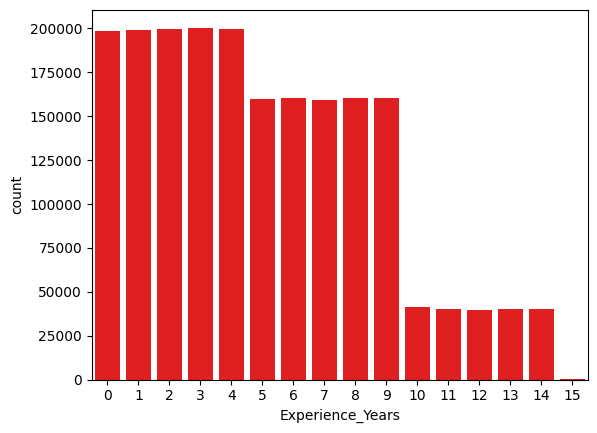

In [29]:
sns.countplot(x="Experience_Years",data=df,color="Red")
plt.show()

In [ ]:
# consider the colums having data-type 'object' only

df.select_dtypes(include='object')

,Employee_ID,Full_Name,Department,Job_Title,Location,Status,Work_Mode
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,"Isaacland, Denmark",Resigned,On-site
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,"Anthonyside, Costa Rica",Active,On-site
2,EMP0000003,Alyssa Martinez,HR,HR Manager,"Port Christinaport, Saudi Arabia",Active,On-site
3,EMP0000004,Nicholas Valdez,IT,Software Engineer,"Port Shelbychester, Antigua and Barbuda",Active,On-site
4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,"Lake Kimberly, Palestinian Territory",Active,On-site
...,...,...,...,...,...,...,...
1999995,EMP1999996,Cody Russell,Operations,Logistics Coordinator,"Casefurt, Serbia",Active,Remote
1999996,EMP1999997,Tracey Smith,IT,Software Engineer,"Dannyport, Kuwait",Active,On-site
1999997,EMP1999998,Tracy Lee,Sales,Business Development Manager,"Craighaven, Nigeria",Active,Remote
1999998,EMP1999999,Michael Roberson,IT,Software Engineer,"Jonathanmouth, Djibouti",Retired,On-site


In [31]:
df.select_dtypes(include='number')

,Performance_Rating,Experience_Years,Salary_INR
0,5,14,1585363
1,2,7,847686
2,1,2,1430084
3,1,1,990689
4,5,0,535082
...,...,...,...
1999995,3,14,657648
1999996,3,4,1030109
1999997,5,1,1313085
1999998,4,2,1479727


In [32]:
df.select_dtypes(include='datetime64[ns]')

,Hire_Date
0,2011-08-10
1,2018-03-02
2,2023-03-20
3,2023-10-12
4,2024-12-09
...,...
1999995,2010-08-31
1999996,2021-05-07
1999997,2024-05-29
1999998,2023-02-14


### Q.1) What is the distribution of Employee Status (Active, Resigned, Retired, Terminated) ?

In [33]:
df['Status'].unique()

array(['Resigned', 'Active', 'Terminated', 'Retired'], dtype=object)

In [35]:
status=df['Status'].value_counts()
status

Status
Active        1401558
Resigned       398660
Retired         99912
Terminated      99870
Name: count, dtype: int64

<Axes: ylabel='count'>

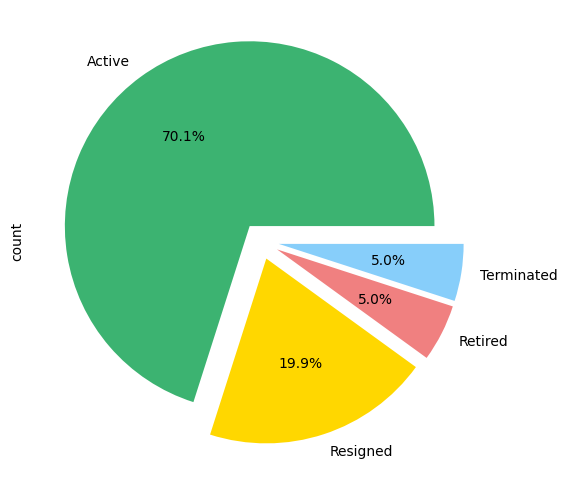

In [57]:
status.plot(
    kind="pie",
    autopct='%1.1f%%',
    figsize=(6,6),
    colors=["mediumseagreen", "gold", "lightcoral", "lightskyblue"],
    explode=[0.1,0.1,0.1,0.1]
)

### Q.2) What is the distribution of work modes (On-site, Remote) ?

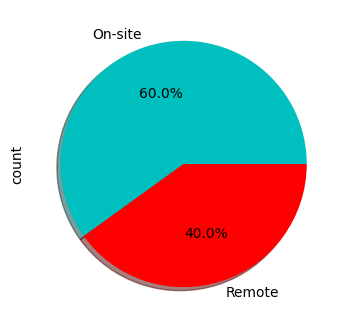

In [79]:
ax = df['Work_Mode'].value_counts().plot(kind='pie', autopct='%1.1f%%',shadow=True, figsize=(6,4),colors='cr')
# ax.bar_label(ax.containers[0]) # for bar chart value 
plt.show()

### Q.3) How many employees are there in each department ?



In [80]:
df.head(2)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686


In [82]:
dept=df['Department'].value_counts()
dept

Department
IT            601042
Sales         400031
Operations    300095
Marketing     240081
Finance       199873
HR            159119
R&D            99759
Name: count, dtype: int64

Text(0, 0.5, 'Employees')

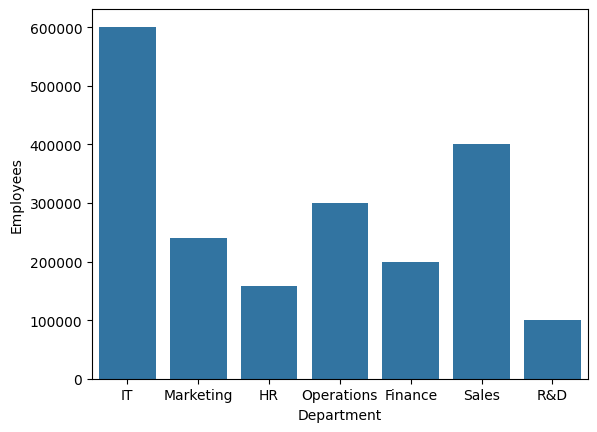

In [87]:
sns.countplot(x="Department",data=df)
plt.xlabel("Department")
plt.ylabel('Employees')
# plt.show()

Text(0, 0.5, 'No of Employees')

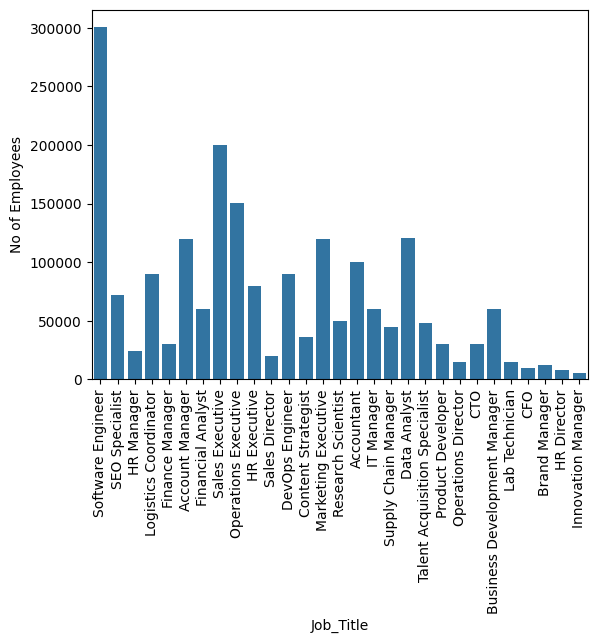

In [ ]:
df['Job_Title'].value_counts()
sns.countplot(x="Job_Title",data=df)
plt.xlabel("Job_Title")
plt.xticks(rotation="vertical")
plt.ylabel('No of Employees')
# plt.show()

### Q.4) What is the average salary by Department ?


Text(0, 0.5, 'Avg_salary')

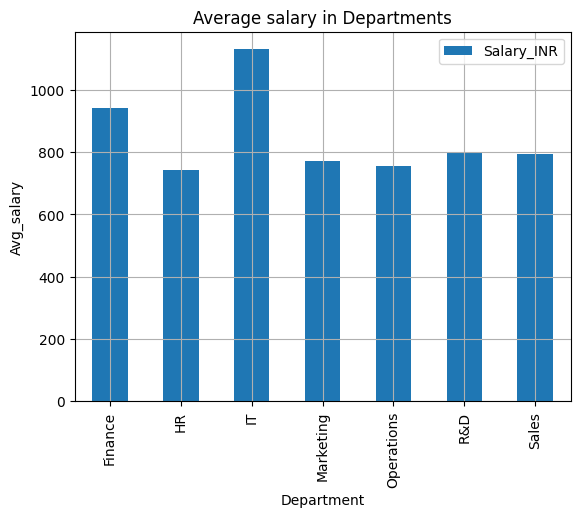

In [98]:
dept=df.groupby("Department")["Salary_INR"].mean()/1000
dept.plot(kind="bar",x=dept.index,y=dept.values,legend=True)
plt.grid()
plt.title("Average salary in Departments")
plt.ylabel("Avg_salary")

### Q.5) Which job title has the highest average salary 

In [102]:
Avg_salary=df.groupby('Job_Title')["Salary_INR"].mean()/1000
highest_job_title = Avg_salary.idxmax() 
highest_salary = Avg_salary.max() 
highest_job_title, highest_salary

('IT Manager', np.float64(2098.1557766339))

### Q.6) What is the average salary in different Departments based on Job Title ?

In [115]:
dept_job = df.groupby(['Department', 'Job_Title'])['Salary_INR'].mean()/1000

dept_job


Department  Job_Title                    
Finance     Accountant                        650.076482
            CFO                               795.015873
            Finance Manager                  1743.241525
            Financial Analyst                1051.522903
HR          HR Director                       800.694437
            HR Executive                      550.548859
            HR Manager                       1252.401915
            Talent Acquisition Specialist     801.422237
IT          CTO                               801.402754
            Data Analyst                      800.996380
            DevOps Engineer                   799.949184
            IT Manager                       2098.155777
            Software Engineer                1199.260843
Marketing   Brand Manager                     803.127787
            Content Strategist                800.760030
            Marketing Executive               798.780404
            SEO Specialist                    

Text(0.5, 1.0, 'Average employee salary per dept and job_title')

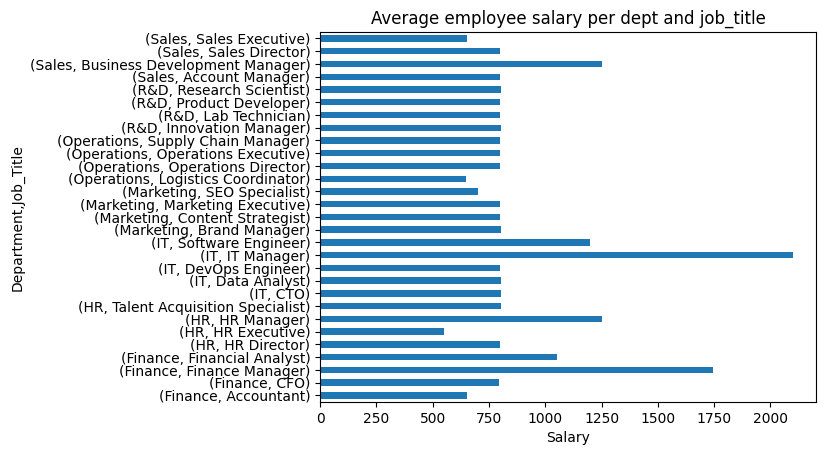

In [118]:
dept_job.plot(kind="barh",x="Department")
plt.xlabel("Salary")
plt.title("Average employee salary per dept and job_title")

### Q.7) How many employees Resigned & Terminated in each department ?

In [121]:
df_filtered = df[df['Status'].isin(['Resigned', 'Terminated'])]

result = df_filtered.groupby(['Department', 'Status']).size().reset_index(name='Count')

result


,Department,Status,Count
0,Finance,Resigned,40238
1,Finance,Terminated,9988
2,HR,Resigned,31736
3,HR,Terminated,7861
4,IT,Resigned,119852
5,IT,Terminated,29881
6,Marketing,Resigned,47793
7,Marketing,Terminated,12044
8,Operations,Resigned,59397
9,Operations,Terminated,14884


### Q.8) How does salary vary with years of experience ?

In [123]:
df.head(2)

df.groupby('Experience_Years')['Salary_INR'].mean()


Experience_Years
0     896737.454775
1     895903.759824
2     896755.652313
3     896861.245240
4     897944.573965
5     896484.084828
6     896012.632467
7     895722.673960
8     897148.361090
9     898482.940577
10    895662.027882
11    901452.750112
12    896432.933416
13    898790.197041
14    895610.790251
15    895647.401051
Name: Salary_INR, dtype: float64

### Q.9) What is the average performance rating by department ?

In [125]:
df.head(2)
df.groupby("Department")['Performance_Rating'].mean()

Department
Finance       2.996818
HR            2.995670
IT            2.998216
Marketing     3.004736
Operations    2.996081
R&D           3.001885
Sales         3.006362
Name: Performance_Rating, dtype: float64

In [129]:
df.head(2)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686


### Q.10) Which Country have the highest concentration of employees ?

In [131]:
df['Country'] = df['Location'].apply(lambda x: x.split(',')[-1].strip())
df['Country'].value_counts()

Country
Congo                     16286
Korea                     16285
Sri Lanka                  8409
Switzerland                8391
British Virgin Islands     8373
                          ...  
Indonesia                  7983
Kazakhstan                 7973
Montenegro                 7972
Bhutan                     7971
Palestinian Territory      7895
Name: count, Length: 243, dtype: int64

### Q.11) Is there a correlation between performance rating and salary ?

In [132]:
df[['Performance_Rating', 'Salary_INR']].corr()


,Performance_Rating,Salary_INR
Performance_Rating,1.000000,-0.000209
Salary_INR,-0.000209,1.000000


### Q.12) How has the number of hires changed over time (per year) ?

In [133]:
df['Hire_Year'] = df['Hire_Date'].dt.year
hires_per_year = df['Hire_Year'].value_counts().sort_index()
hires_per_year


Hire_Year
2010     15520
2011     40089
2012     39765
2013     39988
2014     40202
2015     85984
2016    160249
2017    160363
2018    159658
2019    160202
2020    175460
2021    199366
2022    201373
2023    198982
2024    200001
2025    122798
Name: count, dtype: int64

### Q.13) Compare salaries of Remote vs. On-site employees — is there a significant difference ?

In [140]:
df.groupby('Work_Mode')['Salary_INR'].mean().round(2).reset_index().sort_values('Salary_INR', ascending=False)

,Work_Mode,Salary_INR
1,Remote,896965.33
0,On-site,896835.95


### Q.14) Find the top 10 employees with the highest salary in each department.

In [141]:
df.sort_values('Salary_INR', ascending=False).groupby('Department').head(10)  

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Country,Hire_Year
1697605,EMP1697606,Kathryn Owens,IT,IT Manager,2018-02-22,"Adamsborough, Greenland",5,7,Active,Remote,2999976,Greenland,2018
1284141,EMP1284142,Robert Bowman,IT,IT Manager,2010-10-14,"Lake Brianna, Greece",2,14,Terminated,Remote,2999973,Greece,2010
1912378,EMP1912379,Christina Delgado,IT,IT Manager,2018-06-24,"Lake Jesusview, Chile",5,7,Retired,On-site,2999944,Chile,2018
1904593,EMP1904594,Donald Cohen,IT,IT Manager,2017-11-21,"North Michaelchester, Latvia",4,7,Active,Remote,2999906,Latvia,2017
645146,EMP0645147,Brandon Rodriguez,IT,IT Manager,2016-09-11,"Greenfort, Liechtenstein",2,8,Retired,Remote,2999889,Liechtenstein,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1452254,EMP1452255,Todd Rowe,R&D,Product Developer,2019-03-01,"Garyfort, France",3,6,Active,Remote,1199934,France,2019
1882072,EMP1882073,John Shepard,R&D,Product Developer,2024-05-22,"Crawfordburgh, Tajikistan",1,1,Active,Remote,1199921,Tajikistan,2024
943039,EMP0943040,David Obrien,R&D,Research Scientist,2025-07-21,"Coxland, Christmas Island",4,0,Resigned,Remote,1199919,Christmas Island,2025
137313,EMP0137314,Thomas Bautista,R&D,Research Scientist,2021-01-02,"Lake Codyside, Luxembourg",2,4,Active,On-site,1199917,Luxembourg,2021
